In [1]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/My Drive/Datasheet/credit_card_fraud_10k.csv'

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [3]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [5]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [6]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


In [7]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

**Feature Engineering**

In [8]:
import numpy as np

df['hour_sin'] = np.sin (2 * np.pi * df['transaction_hour']/24)
df['hour_cos'] = np.cos (2 * np.pi * df['transaction_hour']/24)

In [9]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud', 'hour_sin',
       'hour_cos'],
      dtype='object')

**Preprocessing**

In [10]:
Feature = ['amount','hour_sin','hour_cos','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)
print(f"Jumlah data training adalah {len(X_train)} dan jumlah data uji adalah {len(X_test)}")

Jumlah data training adalah 8000 dan jumlah data uji adalah 2000


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount','device_trust_score','velocity_last_24h','cardholder_age']
num_transform = scaler

In [13]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder = 'passthrough')

In [15]:
from sklearn.naive_bayes import GaussianNB

baseline_GNB = GaussianNB()

**Model Baseline**

In [16]:
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model', baseline_GNB)
])

In [17]:
baseline_pipeline.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model', GaussianNB())])

In [18]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, roc_auc_score, confusion_matrix

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
print(f"Akurasi model baseline adalah : {accuracy_baseline:.4f}")
print(f"Precision model baseline adalah : {precision_baseline:.4f}")
print(f"Recall model baseline adalah : {recall_baseline:.4f}")

Akurasi model baseline adalah : 0.9805
Precision model baseline adalah : 0.4211
Recall model baseline adalah : 0.8000


In [20]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.42      0.80      0.55        30

    accuracy                           0.98      2000
   macro avg       0.71      0.89      0.77      2000
weighted avg       0.99      0.98      0.98      2000



In [21]:
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:,1]

In [22]:
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(f"ROC AUC score baseline adalah: {roc_auc_baseline:.4f}")

ROC AUC score baseline adalah: 0.9864


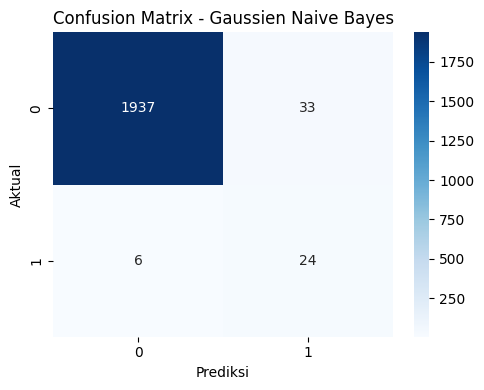

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gaussien Naive Bayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [83]:
from sklearn.inspection import permutation_importance

hasil_importances_baseline = permutation_importance(
    baseline_pipeline,
    X_test,
    y_test,
    scoring= 'f1',
    n_repeats=10,
    random_state=42
)

In [89]:
importances_baseline = pd.DataFrame({
    'Feature':X.columns,
    'Importance': hasil_importances_baseline.importances_mean,
})

In [85]:
fitur_penting_baseline = importances_baseline.sort_values(by="Importance", ascending=False,)
print(fitur_penting_baseline)

               Feature  Importance
5   device_trust_score    0.062625
2             hour_cos    0.058383
3  foreign_transaction    0.044366
4    location_mismatch    0.036258
6    velocity_last_24h    0.017205
1             hour_sin    0.004756
7       cardholder_age    0.001804
0               amount   -0.003882


/tmp/ipykernel_1439/1771151065.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


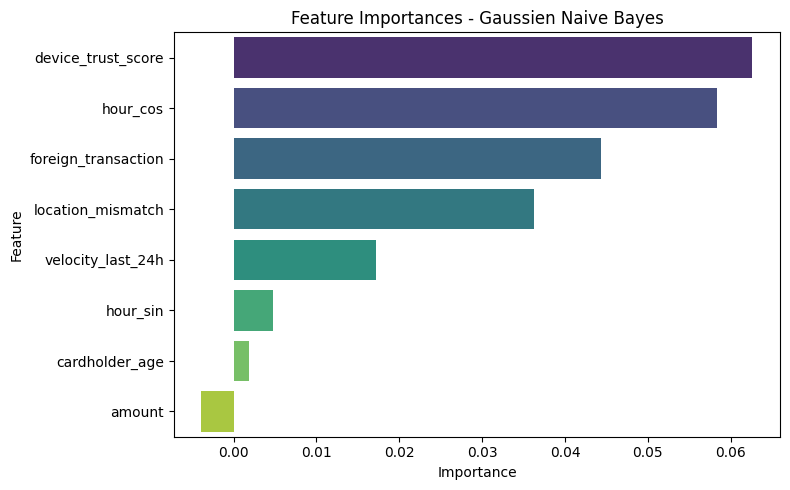

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    data= fitur_penting_baseline,
    x = "Importance",
    y = "Feature",
    palette = 'viridis'
)
plt.title('Feature Importances - Gaussien Naive Bayes')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Model SMOTE**

In [24]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbPipeline

smote_pipeline = imbPipeline([
    ('preprocessor',preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', baseline_GNB)
])

In [25]:
smote_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('smote', SMOTE(random_state=42)), ('model', GaussianNB())])

In [26]:
y_pred_smote = smote_pipeline.predict(X_test)

In [27]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
print(f"Akurasi model smote adalah : {accuracy_smote:.4f}")
print(f"Precision model smote adalah : {precision_smote:.4f}")
print(f"Recall model smote adalah : {recall_smote:.4f}")

Akurasi model smote adalah : 0.9085
Precision model smote adalah : 0.1408
Recall model smote adalah : 1.0000


In [31]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1970
           1       0.14      1.00      0.25        30

    accuracy                           0.91      2000
   macro avg       0.57      0.95      0.60      2000
weighted avg       0.99      0.91      0.94      2000



In [28]:
y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]

In [29]:
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
print(f"ROC AUC score smote adalah: {roc_auc_smote:.4f}")

ROC AUC score smote adalah: 0.9891


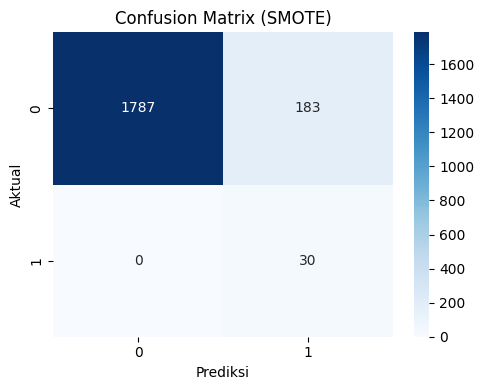

In [30]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**Model Hyperparameter Tuning dengan SMOTE**

In [59]:
params_grid = {
    'var_smoothing' : np.logspace(1, -10, num=10),
    'priors' : [
        [0.99, 0.01],
        [0.95, 0.05],
        [0.90, 0.10],
        [0.80, 0.20],
        [0.50, 0.50]
    ]
}

In [60]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=baseline_GNB,
    param_grid=params_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [61]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


GridSearchCV(cv=5, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'priors': [[0.99, 0.01], [0.95, 0.05], [0.9, 0.1],
                                    [0.8, 0.2], [0.5, 0.5]],
                         'var_smoothing': array([1.00000000e+01, 5.99484250e-01, 3.59381366e-02, 2.15443469e-03,
       1.29154967e-04, 7.74263683e-06, 4.64158883e-07, 2.78255940e-08,
       1.66810054e-09, 1.00000000e-10])},
             scoring='f1', verbose=1)

In [62]:
print(grid_search.best_params_)

{'priors': [0.99, 0.01], 'var_smoothing': np.float64(2.7825594022071144e-08)}


In [63]:
best_GaussienNaiveBayes = grid_search.best_estimator_

In [64]:
y_pred = best_GaussienNaiveBayes.predict(X_test)

In [65]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Akurasi model adalah : {accuracy:.4f}")
print(f"Precision model adalah : {precision:.4f}")
print(f"Recall model adalah : {recall:.4f}")

Akurasi model adalah : 0.9835
Precision model adalah : 0.4651
Recall model adalah : 0.6667


In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1970
           1       0.47      0.67      0.55        30

    accuracy                           0.98      2000
   macro avg       0.73      0.83      0.77      2000
weighted avg       0.99      0.98      0.98      2000



In [67]:
y_prob = best_GaussienNaiveBayes.predict_proba(X_test)[:,1]

In [68]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC score adalah : {roc_auc:.4f}")

ROC AUC score adalah : 0.9865


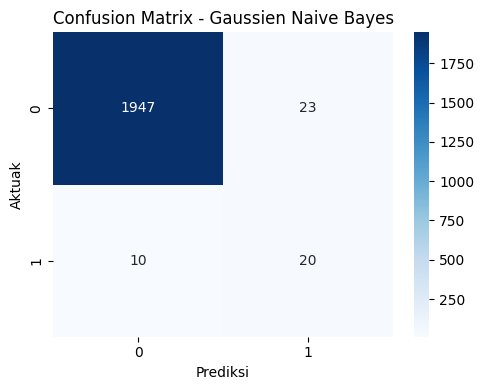

In [69]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gaussien Naive Bayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktuak')
plt.tight_layout()
plt.show()

**Cek fitur penting**

In [71]:
from sklearn.inspection import permutation_importance

hasil_importances = permutation_importance(best_GaussienNaiveBayes, X_test, y_test,
                                           scoring= 'f1',n_repeats=10,random_state=42)

In [77]:
fitur_penting = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': hasil_importances.importances_mean,
})

In [78]:
fitur_penting = fitur_penting.sort_values(by='Importance', ascending=False)
print(fitur_penting)

                 Fitur  Importance
5   device_trust_score    0.248646
4    location_mismatch    0.234579
3  foreign_transaction    0.227352
2             hour_cos    0.158601
1             hour_sin    0.079894
6    velocity_last_24h    0.026415
7       cardholder_age   -0.000761
0               amount   -0.006529


/tmp/ipykernel_1439/3421380070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


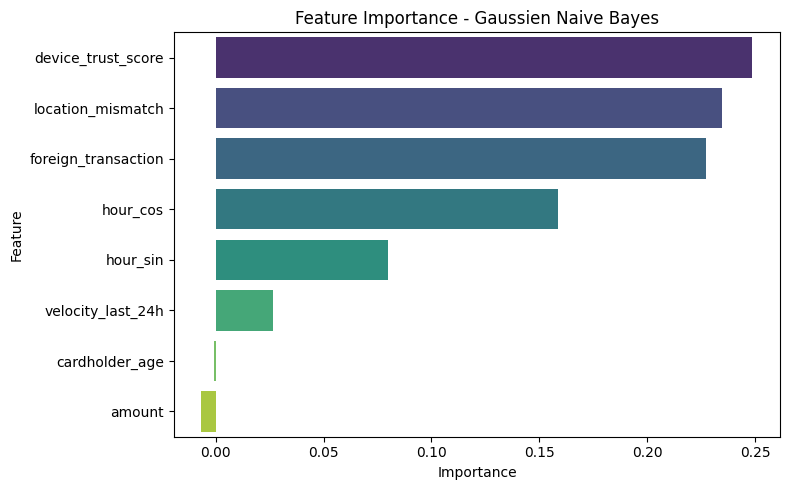

In [81]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=fitur_penting,
    x = 'Importance',
    y = 'Fitur',
    palette = 'viridis'
)
plt.title('Feature Importance - Gaussien Naive Bayes')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [91]:
from google.colab import files
import joblib

joblib.dump(baseline_pipeline, 'Gaussien_Naive_Bayes.joblib')
files.download('Gaussien_Naive_Bayes.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>